# Project 3 - Urban Retail Demand Forecasting: Iowa Liquor Sales Analysis

###Project Background

Urban retail demand forecasting addresses a critical challenge in modern supply chain management: predicting product sales across geographically dispersed city locations to optimize inventory allocation and minimize waste. Traditional forecasting methods struggle with the complex interplay of temporal patterns (weekly seasonality, holiday surges), spatial variation (downtown vs suburban demand), and product-specific preferences that characterize liquor retail.

This project leverages the Iowa Liquor Sales dataset, which is a comprehensive public repository of 33+ million wholesale transactions spanning 2012–2026 — to develop state-of-the-art deep learning models capable of multi-horizon demand predictions. By focusing on Des Moines as a representative urban market, we analyze daily bottle sales across 50+ liquor categories from 100+ stores with precise geolocation coordinates.

The analysis employs LSTM sequence models for baseline temporal forecasting and Transformer architectures with attention mechanisms for advanced pattern recognition, directly addressing the project's objectives of identifying seasonal purchasing patterns, predicting district-level demand, and supporting inventory optimization. These models enable retailers to answer critical questions: How many bottles of vodka should Store #1234 stock next Friday? Will holiday demand spike in the city center

In [3]:
# import the libraries that we want to work with
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import geopandas as gpd

In [4]:
APP_TOKEN   = "50gC06VRjcHyWFMegMcs2rQXz"
CITY        = "DES MOINES"
START_DATE  = "2021-01-01"   # from 2021
END_DATE    = "2025-12-31"   # up to end of 2025
PAGE_SIZE   = 100000

import requests
import pandas as pd

url = "https://data.iowa.gov/api/v3/views/m3tr-qhgy/query.json"

query = (
    f"SELECT * "
    f"WHERE city='{CITY}' "
    f"AND date >= '{START_DATE}' "
    f"AND date <= '{END_DATE}'"
)

params = {
    "pageNumber": 1,
    "pageSize": PAGE_SIZE,
    "app_token": APP_TOKEN,
    "query": query
}

response = requests.get(url, params=params)
resp_json = response.json()


# Convert to DataFrame
dataset = pd.DataFrame(resp_json)
# dataset.columns are inferred from the keys of the dictionaries in the list

In [5]:
dataset.columns


Index(['invoice_line_no', 'date', 'store', 'name', 'address', 'city',
       'zipcode', 'store_location', 'county', 'category', 'category_name',
       'vendor_no', 'vendor_name', 'itemno', 'im_desc', 'pack',
       'bottle_volume_ml', 'state_bottle_cost', 'state_bottle_retail',
       'sale_bottles', 'sale_dollars', 'sale_liters', 'sale_gallons', ':id',
       ':version', ':created_at', ':updated_at', ':@computed_region_3r5t_5243',
       ':@computed_region_wnea_7qqw', ':@computed_region_i9mz_6gmt',
       ':@computed_region_uhgg_e8y2', ':@computed_region_e7ym_nrbf',
       'county_number'],
      dtype='object')

In [6]:
dataset = dataset.drop(columns=[':id', ':version', ':created_at', ':updated_at',':@computed_region_3r5t_5243',
       ':@computed_region_wnea_7qqw', ':@computed_region_i9mz_6gmt',
       ':@computed_region_uhgg_e8y2', ':@computed_region_e7ym_nrbf'])
dataset.columns

Index(['invoice_line_no', 'date', 'store', 'name', 'address', 'city',
       'zipcode', 'store_location', 'county', 'category', 'category_name',
       'vendor_no', 'vendor_name', 'itemno', 'im_desc', 'pack',
       'bottle_volume_ml', 'state_bottle_cost', 'state_bottle_retail',
       'sale_bottles', 'sale_dollars', 'sale_liters', 'sale_gallons',
       'county_number'],
      dtype='object')

In [7]:
dataset.shape

(100000, 24)

In [8]:
dataset.tail()

,invoice_line_no,date,store,name,address,city,zipcode,store_location,county,category,...,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,county_number
99995,INV-56922400001,2023-03-24T00:00:00.000,5375,CASEY'S GENERAL STORE # 3518/ DES MOINES,1907 ARMY POST RD,DES MOINES,50315,"{'type': 'Point', 'coordinates': [-93.64171, 4...",POLK,1012100,...,CROWN ROYAL REGAL APPLE MINI,10,50,9.95,14.93,10,149.30,0.50,0.13,NaN
99996,INV-56923700070,2023-03-24T00:00:00.000,6303,WORLD LIQUOR & TOBACCO + VAPORS / DES MOINES,3200 SOUTHEAST 14TH STREET,DES MOINES,50320,"{'type': 'Point', 'coordinates': [-93.59738, 4...",POLK,1011400,...,JACK DANIELS TENNESSEE HONEY,12,750,15.91,23.87,1,23.87,0.75,0.19,NaN
99997,INV-56924100009,2023-03-24T00:00:00.000,4601,KUM & GO #4110 / GUTHRIE DM,2110 GUTHRIE AVE,DES MOINES,50317,"{'type': 'Point', 'coordinates': [-93.57903, 4...",POLK,1011200,...,JIM BEAM PEACH,12,750,11.00,16.50,1,16.50,0.75,0.19,NaN
99998,INV-56897800028,2023-03-23T00:00:00.000,6299,CASEY'S #3953 / DES MOINES,3121 FOREST AVENUE,DES MOINES,50311,"{'type': 'Point', 'coordinates': [-93.66063, 4...",POLK,1011400,...,JACK DANIELS TENNESSEE FIRE MINI,12,50,11.50,17.25,1,17.25,0.05,0.01,NaN
99999,INV-56922000019,2023-03-24T00:00:00.000,4140,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,DES MOINES,50313,"{'type': 'Point', 'coordinates': [-93.61897, 4...",POLK,1031100,...,NIKOLAI VODKA,12,750,3.30,4.95,12,59.40,9.00,2.37,NaN


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   invoice_line_no      100000 non-null  object
 1   date                 100000 non-null  object
 2   store                100000 non-null  object
 3   name                 100000 non-null  object
 4   address              100000 non-null  object
 5   city                 100000 non-null  object
 6   zipcode              100000 non-null  object
 7   store_location       96148 non-null   object
 8   county               100000 non-null  object
 9   category             100000 non-null  object
 10  category_name        100000 non-null  object
 11  vendor_no            100000 non-null  object
 12  vendor_name          100000 non-null  object
 13  itemno               100000 non-null  object
 14  im_desc              100000 non-null  object
 15  pack                 100000 non-nul

In [10]:
dataset.to_parquet("iowa_liquor_desmoines_2020_2025.parquet")
dataset.to_csv("iowa_liquor_desmoines_2020_2025.csv")

In [11]:
# need to convert the data types
numerical_col = ['store','pack','bottle_volume_ml', 'state_bottle_cost', 'state_bottle_retail',
       'sale_bottles', 'sale_dollars', 'sale_liters', 'sale_gallons']
for col in numerical_col:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset['date'] = pd.to_datetime(dataset['date'])


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   invoice_line_no      100000 non-null  object        
 1   date                 100000 non-null  datetime64[ns]
 2   store                100000 non-null  int64         
 3   name                 100000 non-null  object        
 4   address              100000 non-null  object        
 5   city                 100000 non-null  object        
 6   zipcode              100000 non-null  object        
 7   store_location       96148 non-null   object        
 8   county               100000 non-null  object        
 9   category             100000 non-null  object        
 10  category_name        100000 non-null  object        
 11  vendor_no            100000 non-null  object        
 12  vendor_name          100000 non-null  object        
 13  itemno         

In [13]:
dataset.head()

,invoice_line_no,date,store,name,address,city,zipcode,store_location,county,category,...,im_desc,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,county_number
0,INV-50365700089,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,"{'type': 'Point', 'coordinates': [-93.703373, ...",POLK,1031200,...,"SMIRNOFF RED, WHITE & BERRY",6,1750,14.75,22.13,2,44.26,3.50,0.92,NaN
1,INV-50298300021,2022-08-12,4169,SUPER QUICK 2 / HUBBELL,1824 HUBBELL AVE,DES MOINES,50317,NaN,POLK,1022200,...,1800 ANEJO,6,750,22.41,33.62,3,100.86,2.25,0.59,NaN
2,INV-50365700134,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,"{'type': 'Point', 'coordinates': [-93.703373, ...",POLK,1062400,...,ADMIRAL NELSON SPICED,6,1750,11.55,17.33,2,34.66,3.50,0.92,NaN
3,INV-50365700065,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,"{'type': 'Point', 'coordinates': [-93.703373, ...",POLK,1031200,...,NEW AMSTERDAM RASPBERRY,24,375,3.50,5.25,5,26.25,1.87,0.49,NaN
4,INV-50365700122,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,"{'type': 'Point', 'coordinates': [-93.703373, ...",POLK,1041100,...,GILBEYS GIN,12,750,5.00,7.50,3,22.50,2.25,0.59,NaN


In [14]:
# Convert GeoJSON dictionaries to proper geometry objects
def geojson_to_point(geojson_obj):
    if pd.isna(geojson_obj):
        return None
    # geojson_obj is already a dictionary, no need for json.loads or .replace()
    if isinstance(geojson_obj, dict) and 'coordinates' in geojson_obj:
        # GeoPandas expects [longitude, latitude] where coordinates are [lon, lat]
        return gpd.points_from_xy([geojson_obj['coordinates'][0]], [geojson_obj['coordinates'][1]])[0]
    return None

dataset['geometry'] = dataset['store_location'].apply(geojson_to_point)

#Convert to GeoDataFrame
# Use the 'dataset' DataFrame which now contains the 'geometry' column
dataset = gpd.GeoDataFrame(dataset, geometry='geometry', crs="EPSG:4326")

# Extract lat/lon (Handling potential None values)
dataset['Latitude'] = dataset.geometry.y
dataset['Longitude'] = dataset.geometry.x
dataset= dataset.drop(columns=['store_location'])

dataset.head()

,invoice_line_no,date,store,name,address,city,zipcode,county,category,category_name,...,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,county_number,geometry,Latitude,Longitude
0,INV-50365700089,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,14.75,22.13,2,44.26,3.50,0.92,NaN,POINT (-93.70337 41.57881),41.578809,-93.703373
1,INV-50298300021,2022-08-12,4169,SUPER QUICK 2 / HUBBELL,1824 HUBBELL AVE,DES MOINES,50317,POLK,1022200,100% AGAVE TEQUILA,...,22.41,33.62,3,100.86,2.25,0.59,NaN,None,NaN,NaN
2,INV-50365700134,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1062400,SPICED RUM,...,11.55,17.33,2,34.66,3.50,0.92,NaN,POINT (-93.70337 41.57881),41.578809,-93.703373
3,INV-50365700065,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,3.50,5.25,5,26.25,1.87,0.49,NaN,POINT (-93.70337 41.57881),41.578809,-93.703373
4,INV-50365700122,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1041100,AMERICAN DRY GINS,...,5.00,7.50,3,22.50,2.25,0.59,NaN,POINT (-93.70337 41.57881),41.578809,-93.703373


## DATA QUALITY ASSESSMENT

In [15]:
# According to the below information, there is no missing values in each column
print("🔍 DATA QUALITY ASSESSMENT")
print("=" * 50)

# 1. Basic info
print(f"Dataset shape: {dataset.shape}")
print(f"Memory usage: {dataset.memory_usage(deep=True).sum() / 1024:.1f} KB")

# 2. Data types
print("\n📋 Data Types:")
print(dataset.dtypes)

# 3. Missing values analysis
print("\n❌ Missing Values:")
missing_counts = dataset.isnull().sum()
missing_percentages = (missing_counts / len(dataset)) * 100
missing_df = pd.DataFrame({
    'Count': missing_counts,
    'Percentage': missing_percentages
})
print(missing_df[missing_df['Count'] > 0])

# 4. Duplicate rows
duplicates = dataset.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates}")

# 5. Basic statistics
print("\n📈 Numerical Statistics:")
print(dataset.describe())

🔍 DATA QUALITY ASSESSMENT
Dataset shape: (100000, 26)
Memory usage: 85339.3 KB

📋 Data Types:
invoice_line_no                object
date                   datetime64[ns]
store                           int64
name                           object
address                        object
city                           object
zipcode                        object
county                         object
category                       object
category_name                  object
vendor_no                      object
vendor_name                    object
itemno                         object
im_desc                        object
pack                            int64
bottle_volume_ml                int64
state_bottle_cost             float64
state_bottle_retail           float64
sale_bottles                    int64
sale_dollars                  float64
sale_liters                   float64
sale_gallons                  float64
county_number                  object
geometry                     geo

In [16]:
dataset = dataset.drop(columns=['county_number'])
dataset.head()

,invoice_line_no,date,store,name,address,city,zipcode,county,category,category_name,...,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,geometry,Latitude,Longitude
0,INV-50365700089,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,1750,14.75,22.13,2,44.26,3.50,0.92,POINT (-93.70337 41.57881),41.578809,-93.703373
1,INV-50298300021,2022-08-12,4169,SUPER QUICK 2 / HUBBELL,1824 HUBBELL AVE,DES MOINES,50317,POLK,1022200,100% AGAVE TEQUILA,...,750,22.41,33.62,3,100.86,2.25,0.59,None,NaN,NaN
2,INV-50365700134,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1062400,SPICED RUM,...,1750,11.55,17.33,2,34.66,3.50,0.92,POINT (-93.70337 41.57881),41.578809,-93.703373
3,INV-50365700065,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,375,3.50,5.25,5,26.25,1.87,0.49,POINT (-93.70337 41.57881),41.578809,-93.703373
4,INV-50365700122,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1041100,AMERICAN DRY GINS,...,750,5.00,7.50,3,22.50,2.25,0.59,POINT (-93.70337 41.57881),41.578809,-93.703373


In [17]:
nan_rows = dataset[dataset['geometry'].isna() |
               dataset['Latitude'].isna() |
               dataset['Longitude'].isna()]
nan_rows.head()
nan_rows.shape

(3852, 25)

In [18]:
# Extract latitude and longitude from the geometry
nan_rows = pd.read_csv("/content/drive/MyDrive/new_project_2026/nan_rows (1).csv")
nan_rows.head()

,Unnamed: 0,invoice_line_no,date,store,name,address,city,zipcode,county,category,...,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,geometry,Latitude,Longitude
0,1,INV-50298300021,2022-08-12,4169,SUPER QUICK 2 / HUBBELL,1824 HUBBELL AVE,DES MOINES,50317,POLK,1022200,...,750,22.41,33.62,3,100.86,2.25,0.59,POINT (-93.5865209 41.5963199),41.596320,-93.586521
1,37,INV-50258500014,2022-08-11,6264,MLK LIQUOR LLC / DES MOINES,3424 MARTIN LUTHER KING JUNIOR PARKWAY,DES MOINES,50310,POLK,1022200,...,750,35.99,53.99,6,323.94,4.50,1.18,POINT (-84.5006407 33.7552163),33.755216,-84.500641
2,38,INV-50276600006,2022-08-12,5338,KUM & GO #539/ NW 2ND AVE,5050 NW 2ND AVE,DES MOINES,50313,POLK,1012100,...,50,9.95,14.93,4,59.72,0.20,0.05,POINT (-77.0134783 38.9563018),38.956302,-77.013478
3,62,INV-50316600005,2022-08-15,2528,HY-VEE FOOD STORE #3 / DES MOINES,3221 SE 14TH ST,DES MOINES,50315,POLK,1052100,...,1750,49.99,74.99,6,449.94,10.50,2.77,POINT (-122.3751415 47.6491308),47.649131,-122.375141
4,75,INV-50279400047,2022-08-12,6118,CASH SAVER #33 / DES MOINES,1320 E EUCLID AVE,DES MOINES,50313,POLK,1062100,...,1750,7.50,11.25,6,67.50,10.50,2.77,POINT (-89.29079298 48.36669328),48.366693,-89.290793


In [19]:
# Merge nan_rows into dataset, prioritizing nan_rows data for matching stores
dataset_final = dataset.merge(
    nan_rows[['invoice_line_no', 'Latitude', 'Longitude', 'geometry']],  # Key spatial columns
    on='invoice_line_no',
    how='left',
    suffixes=('', '_filled')
)

# Replace NaN values with filled values
spatial_cols = ['Latitude', 'Longitude', 'geometry']
for col in spatial_cols:
    dataset_final[col] = dataset_final[f'{col}_filled'].fillna(dataset_final[col])
    dataset_final = dataset_final.drop(f'{col}_filled', axis=1)

print("✅ NaN rows replaced via merge!")
dataset_final.head()

✅ NaN rows replaced via merge!


/tmp/ipykernel_7706/3859033890.py:12: UserWarning: Geometry column does not contain geometry.
  dataset_final[col] = dataset_final[f'{col}_filled'].fillna(dataset_final[col])


,invoice_line_no,date,store,name,address,city,zipcode,county,category,category_name,...,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,geometry,Latitude,Longitude
0,INV-50365700089,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,1750,14.75,22.13,2,44.26,3.50,0.92,POINT (-93.703373 41.578809),41.578809,-93.703373
1,INV-50298300021,2022-08-12,4169,SUPER QUICK 2 / HUBBELL,1824 HUBBELL AVE,DES MOINES,50317,POLK,1022200,100% AGAVE TEQUILA,...,750,22.41,33.62,3,100.86,2.25,0.59,POINT (-93.5865209 41.5963199),41.596320,-93.586521
2,INV-50365700134,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1062400,SPICED RUM,...,1750,11.55,17.33,2,34.66,3.50,0.92,POINT (-93.703373 41.578809),41.578809,-93.703373
3,INV-50365700065,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1031200,AMERICAN FLAVORED VODKA,...,375,3.50,5.25,5,26.25,1.87,0.49,POINT (-93.703373 41.578809),41.578809,-93.703373
4,INV-50365700122,2022-08-16,10029,ROYAL MART / DES MOINES,111 SOUTHWEST 63RD STREET,DES MOINES,50312,POLK,1041100,AMERICAN DRY GINS,...,750,5.00,7.50,3,22.50,2.25,0.59,POINT (-93.703373 41.578809),41.578809,-93.703373


In [30]:
dataset_final.to_csv("iowa_liquor_desmoines_2020_2025_final.csv")

In [20]:
dataset_final.isnull().sum()

,0
invoice_line_no,0
date,0
store,0
name,0
address,0
city,0
zipcode,0
county,0
category,0
category_name,0


I am going to keep it 12 columns for my feature engineering part. So I am going to drop other columns.

In [21]:
# Select only forecasting-essential columns
forecast_cols = [
    'date','name', 'store', 'city','zipcode', 'Latitude', 'Longitude',
    'category_name', 'itemno', 'vendor_name',
    'sale_bottles', 'sale_dollars', 'state_bottle_retail', 'pack'
]

df_forecast = dataset_final[forecast_cols].copy()
print(f"✅ Slim dataset: {df_forecast.shape}")
df_forecast.head()

✅ Slim dataset: (100000, 14)


,date,name,store,city,zipcode,Latitude,Longitude,category_name,itemno,vendor_name,sale_bottles,sale_dollars,state_bottle_retail,pack
0,2022-08-16,ROYAL MART / DES MOINES,10029,DES MOINES,50312,41.578809,-93.703373,AMERICAN FLAVORED VODKA,77994,DIAGEO AMERICAS,2,44.26,22.13,6
1,2022-08-12,SUPER QUICK 2 / HUBBELL,4169,DES MOINES,50317,41.596320,-93.586521,100% AGAVE TEQUILA,89230,PROXIMO,3,100.86,33.62,6
2,2022-08-16,ROYAL MART / DES MOINES,10029,DES MOINES,50312,41.578809,-93.703373,SPICED RUM,43028,HEAVEN HILL BRANDS,2,34.66,17.33,6
3,2022-08-16,ROYAL MART / DES MOINES,10029,DES MOINES,50312,41.578809,-93.703373,AMERICAN FLAVORED VODKA,36617,E & J GALLO WINERY,5,26.25,5.25,24
4,2022-08-16,ROYAL MART / DES MOINES,10029,DES MOINES,50312,41.578809,-93.703373,AMERICAN DRY GINS,30236,JIM BEAM BRANDS,3,22.50,7.50,12


In [22]:
# we can find total demand for each store using this
daily_demand = dataset.groupby(['date','zipcode','store']).agg({
    'sale_bottles': 'sum',
    'sale_dollars': 'sum'
}).reset_index()
daily_demand.head()
#There are different stores available in each suburbs

,date,zipcode,store,sale_bottles,sale_dollars
0,2022-04-01,50309,4942,101,1273.00
1,2022-04-01,50309,4997,955,4043.00
2,2022-04-01,50309,5051,448,3256.33
3,2022-04-01,50310,6264,6,238.44
4,2022-04-01,50311,2626,281,3556.08


In [23]:
daily_demand.shape

(2588, 5)

## Daily Liquor Sales - Des Moines (2020+)

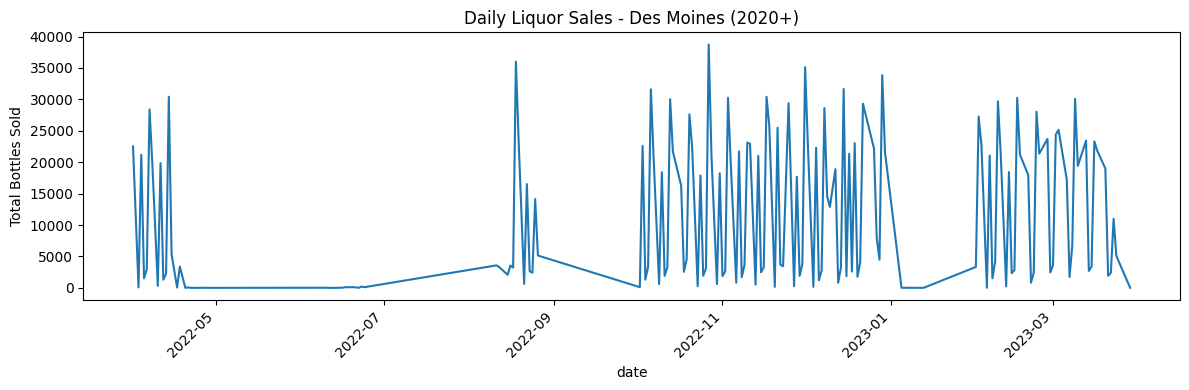

In [24]:
import matplotlib.pyplot as plt
daily_sales = daily_demand.groupby('date')['sale_bottles'].sum()
daily_sales.plot(figsize=(12, 4))
plt.title('Daily Liquor Sales - Des Moines (2020+)')
plt.ylabel('Total Bottles Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top 10 Liquor Categories by Total Volume Sold

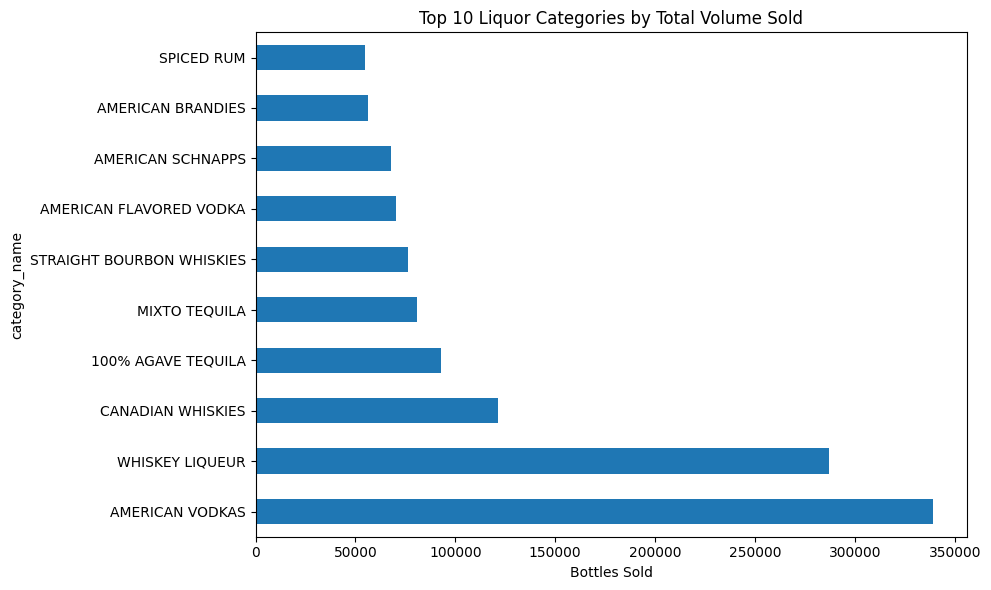

category_name
AMERICAN VODKAS              339083
WHISKEY LIQUEUR              287193
CANADIAN WHISKIES            121131
100% AGAVE TEQUILA            93014
MIXTO TEQUILA                 80761
STRAIGHT BOURBON WHISKIES     76392
AMERICAN FLAVORED VODKA       70455
AMERICAN SCHNAPPS             67877
AMERICAN BRANDIES             56084
SPICED RUM                    54806
Name: sale_bottles, dtype: int64


In [25]:
top_categories = df_forecast.groupby('category_name')['sale_bottles'].sum().nlargest(10)
top_categories.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Liquor Categories by Total Volume Sold')
plt.xlabel('Bottles Sold')
plt.tight_layout()
plt.show()
print(top_categories)

## Total demand per store over the whole period

    store                                 name        city  total_bottles
12   2633         HY-VEE #3 / BDI / DES MOINES  DES MOINES         358822
52   4829                       CENTRAL CITY 2  DES MOINES         320168
0    2190            CENTRAL CITY LIQUOR, INC.  DES MOINES          65165
10   2626  HY-VEE DRUGSTORE / UNIVERSITY / DSM  DES MOINES          41543
9    2561      HY-VEE FOOD STORE / FLEUR / DSM  DES MOINES          37164
68   5443               1ST STOP BEVERAGE SHOP  DES MOINES          34743
74   5600                      H & A MINI MART  DES MOINES          33638
64   5145                 SOUTH SIDE FOOD MART  DES MOINES          31446
3    2527    HY-VEE FOOD STORE #5 / DES MOINES  DES MOINES          30357
89   6256           821 SQ LIQUOR / DES MOINES  DES MOINES          29904


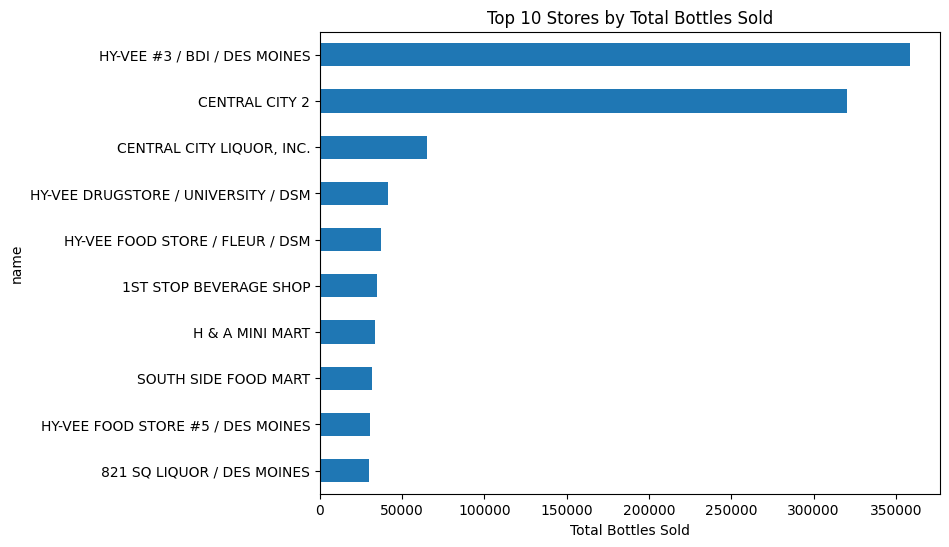

In [26]:
# Total demand per store over the whole period
store_total = (
    df_forecast
    .groupby(['store', 'name', 'city'], as_index=False)['sale_bottles']
    .sum()
    .rename(columns={'sale_bottles': 'total_bottles'})
)

# Sort and take top 10
top10_stores = store_total.sort_values('total_bottles', ascending=False).head(10)

print(top10_stores)
top10_stores.plot(
    x='name', y='total_bottles', kind='barh', figsize=(8, 6), legend=False
)
plt.gca().invert_yaxis()
plt.title('Top 10 Stores by Total Bottles Sold')
plt.xlabel('Total Bottles Sold')
plt.show()


In [27]:
# YOUR FORECASTING TARGET: daily demand per category
forecast_data = dataset.groupby(['date', 'category_name'])['sale_bottles'].sum().reset_index()
print("Forecast dataset shape:", forecast_data.shape)
print(forecast_data.head(10))
print("\nUnique categories:", forecast_data['category_name'].nunique())


Forecast dataset shape: (5130, 3)
        date                         category_name  sale_bottles
0 2022-04-01                    100% AGAVE TEQUILA           981
1 2022-04-01                         AGED DARK RUM            33
2 2022-04-01                     AMERICAN BRANDIES          1286
3 2022-04-01          AMERICAN CORDIALS & LIQUEURS           266
4 2022-04-01  AMERICAN DISTILLED SPIRITS SPECIALTY             8
5 2022-04-01                     AMERICAN DRY GINS           120
6 2022-04-01               AMERICAN FLAVORED VODKA           794
7 2022-04-01                     AMERICAN SCHNAPPS           480
8 2022-04-01                       AMERICAN VODKAS          4583
9 2022-04-01                      BLENDED WHISKIES           707

Unique categories: 44


   zipcode  total_bottles
5    50314         443648
9    50320         429356
6    50315         199056
8    50317         197043
10   50321         103394
4    50313          96822
1    50310          86194
2    50311          77703
0    50309          62002
7    50316          61192


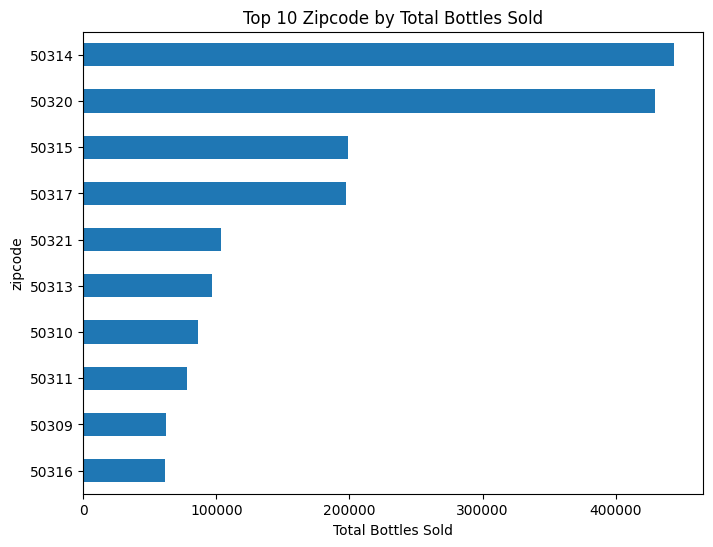

In [28]:
# Total demand per store over the whole period
store_total = (
    df_forecast
    .groupby(['zipcode'], as_index=False)['sale_bottles']
    .sum()
    .rename(columns={'sale_bottles': 'total_bottles'})
)

# Sort and take top 10
top10_zip = store_total.sort_values('total_bottles', ascending=False).head(10)

print(top10_zip)
top10_zip.plot(
    x='zipcode', y='total_bottles', kind='barh', figsize=(8, 6), legend=False
)
plt.gca().invert_yaxis()
plt.title('Top 10 Zipcode by Total Bottles Sold')
plt.xlabel('Total Bottles Sold')
plt.show()

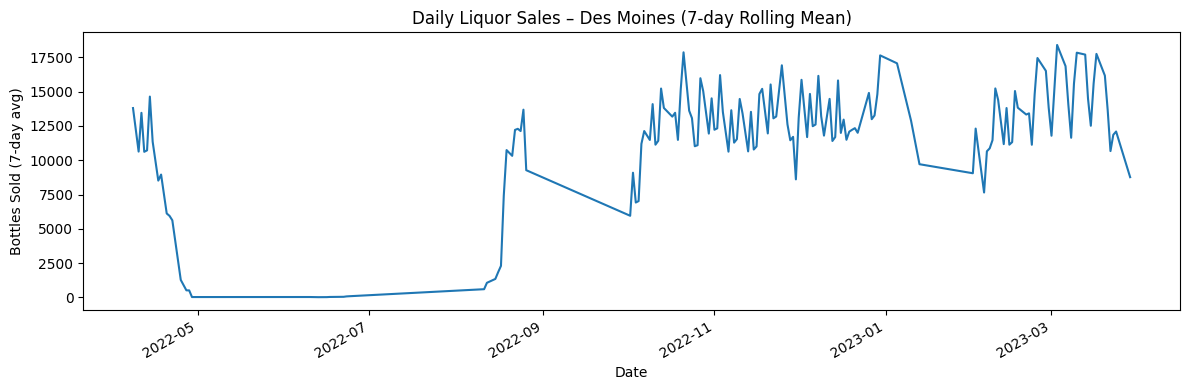

In [29]:
daily_sales = daily_demand.groupby('date')['sale_bottles'].sum().sort_index()

plt.figure(figsize=(12, 4))
daily_sales.rolling(7).mean().plot()
plt.title('Daily Liquor Sales – Des Moines (7‑day Rolling Mean)')
plt.ylabel('Bottles Sold (7‑day avg)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()
